# Hybrid RF/FSO Communication Channel Model

**Author:** Prashant Shrestha | University of Adelaide — Master of Data Science (2025)

---

### Background
Hybrid Radio Frequency / Free-Space Optical (RF/FSO) communication systems combine two wireless technologies to improve reliability:
- **FSO (Free-Space Optical)** — high bandwidth but vulnerable to weather (fog, rain, turbulence)
- **RF (Radio Frequency)** — lower bandwidth but more weather-resilient

Accurately predicting signal attenuation under different weather conditions allows engineers to design systems that switch between channels at the right time, maintaining reliable communication.

### Objective
Build Random Forest regression models to predict FSO and RF channel attenuation from weather and environmental features, and compare two modelling strategies:
1. **Specific Model** — a separate model trained per weather condition (SYNOP code)
2. **Generic Model** — a single model trained across all conditions

### Pipeline
1. Data inspection and cleaning
2. Exploratory data analysis — distributions, correlations, time trends
3. Data balancing by SYNOP weather condition
4. Feature selection via backward elimination
5. Model training and comparison

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# Dataset file — ensure RFLFSODataFull.csv is in the same directory as this notebook
rflfso_data = pd.read_csv('RFLFSODataFull.csv')

## 2. Data Inspection

In [2]:
# Overview: shape, column names, dtypes, null counts
print("Columns:", rflfso_data.columns.tolist())
rflfso_data.info()

Columns: ['FSO_Att', 'RFL_Att', 'AbsoluteHumidity', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity', 'SYNOPCode', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Time', 'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection', 'WindSpeed', 'WindSpeedMax', 'WindSpeedMin']
<class 'pandas.DataFrame'>
RangeIndex: 91379 entries, 0 to 91378
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FSO_Att                91379 non-null  float64
 1   RFL_Att                91379 non-null  float64
 2   AbsoluteHumidity       91379 non-null  float64
 3   AbsoluteHumidityMax    91379 non-null  float64
 4   AbsoluteHumidityMin    91379 non-null  float64
 5   Distance               91379 non-null  float64
 6   Frequency              

In [3]:
rflfso_data.head()

,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMax,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin
0,7.913289,6.927868,17.595709,17.615907,17.340148,2115.338398,83500000000,0.0,0.0,0.0,...,26.603030,24.680849,9,65884.51846,72336.362233,65617.543754,88.755450,3.057066,6.863808,3.007939
1,7.451176,4.412096,17.549693,17.572415,17.299439,2113.999257,73500000000,0.0,0.0,0.0,...,26.377164,24.313108,9,64963.41092,68753.386153,60379.327485,99.790057,2.727910,6.468903,2.537393
2,7.072747,6.268740,17.290230,17.644014,16.037894,2118.689047,83500000000,0.0,0.0,0.0,...,27.670822,23.150277,10,54794.28107,54821.773817,50850.155963,65.730085,1.674810,2.826916,1.640809
3,6.949288,4.317853,16.820880,17.066776,15.895622,2114.632339,73500000000,0.0,0.0,0.0,...,26.522100,23.174815,10,50205.64159,52519.927530,45374.510898,88.127497,0.962068,2.780643,0.886951
4,7.361052,6.114514,16.813820,17.953974,15.227225,2116.786055,83500000000,0.0,0.0,0.0,...,26.305736,24.864100,10,59038.32599,64418.329138,54461.246506,84.167414,1.881007,4.476298,1.874052


In [4]:
# Confirm no missing values
print("Missing values:")
print(rflfso_data.isna().sum())

Missing values:
FSO_Att                  0
RFL_Att                  0
AbsoluteHumidity         0
AbsoluteHumidityMax      0
AbsoluteHumidityMin      0
Distance                 0
Frequency                0
Particulate              0
ParticulateMax           0
ParticulateMin           0
RainIntensity            0
RainIntensityMax         0
RainIntensityMin         0
RelativeHumidity         0
SYNOPCode                0
Temperature              0
TemperatureDifference    0
TemperatureMax           0
TemperatureMin           0
Time                     0
Visibility               0
VisibilityMax            0
VisibilityMin            0
WindDirection            0
WindSpeed                0
WindSpeedMax             0
WindSpeedMin             0
dtype: int64


In [5]:
# Ensure SYNOPCode is stored as integer (weather condition category)
rflfso_data['SYNOPCode'] = rflfso_data['SYNOPCode'].astype(int)

print("Descriptive Statistics:")
rflfso_data.describe()

Descriptive Statistics:


,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMax,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin
count,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,9.137900e+04,91379.000000,91379.000000,91379.000000,...,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000,91379.000000
mean,6.769458,11.619098,9.553919,10.032760,9.076251,3297.930328,7.850005e+10,27.065979,28.417120,25.717089,...,13.166020,11.904558,11.373193,32986.417484,34636.684647,31331.618978,89.043304,0.739065,1.851020,0.702242
std,3.903843,3.438873,5.858577,6.162798,5.575927,1224.305893,5.000027e+09,72.134023,75.761896,68.595239,...,9.589755,8.694028,6.942229,24713.874445,25978.845228,23497.873065,26.415610,0.871314,1.762698,0.828796
min,0.788363,0.027142,1.141556,1.238270,1.049744,2012.000148,7.350000e+10,0.000000,0.000000,0.000000,...,-6.693373,-7.270075,0.000000,10.151990,11.029667,9.484346,0.000000,0.000000,0.000000,0.000000
25%,3.473063,10.829331,4.958993,5.205861,4.709511,2019.431812,7.350000e+10,0.000000,0.000000,0.000000,...,4.905387,4.438425,5.000000,11158.598400,11721.447542,10588.793237,82.976727,0.076749,0.512667,0.072912
50%,6.336167,11.856560,6.870737,7.205499,6.524046,2959.863686,8.350000e+10,0.000000,0.000000,0.000000,...,10.803943,9.774467,11.000000,26378.636210,27686.214032,25047.188462,90.867362,0.437995,1.323101,0.416274
75%,8.664984,12.847944,14.049470,14.782679,13.379256,4820.890157,8.350000e+10,16.947618,17.775980,16.038090,...,22.470382,20.322434,17.000000,53493.821285,56092.212376,50797.690402,98.482652,1.088621,2.681788,1.036574
max,32.455222,46.893150,24.790883,26.407305,24.268431,4827.999971,8.350000e+10,1621.001906,1753.747866,1500.666382,...,40.771383,36.724191,23.000000,75004.999150,82503.130084,74999.343414,360.000000,7.799086,16.421115,7.252319


## 3. Exploratory Data Analysis

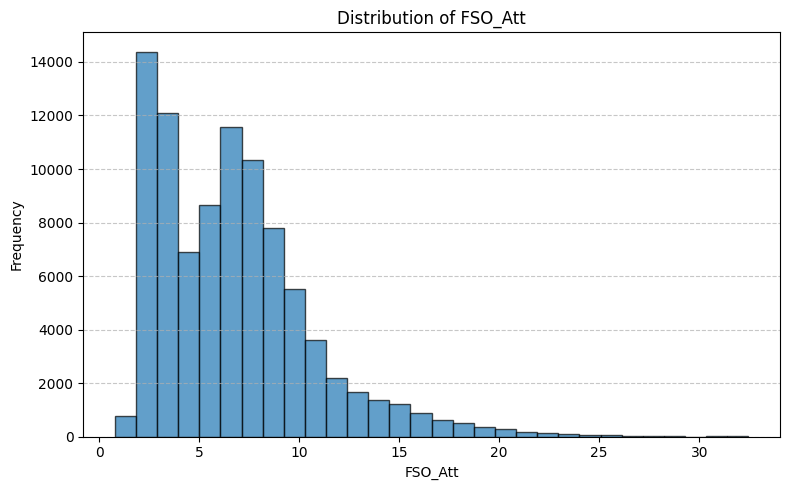

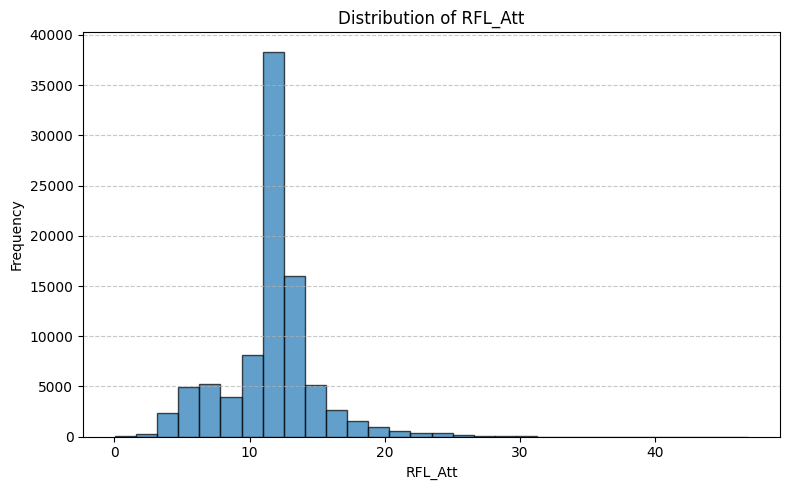

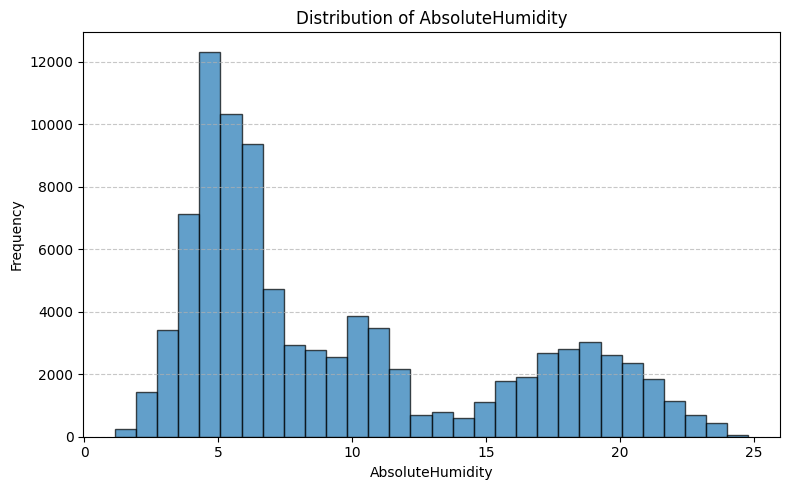

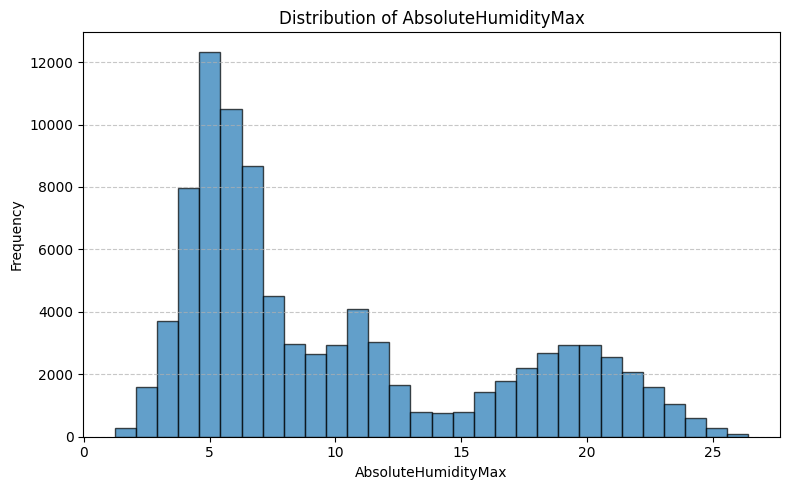

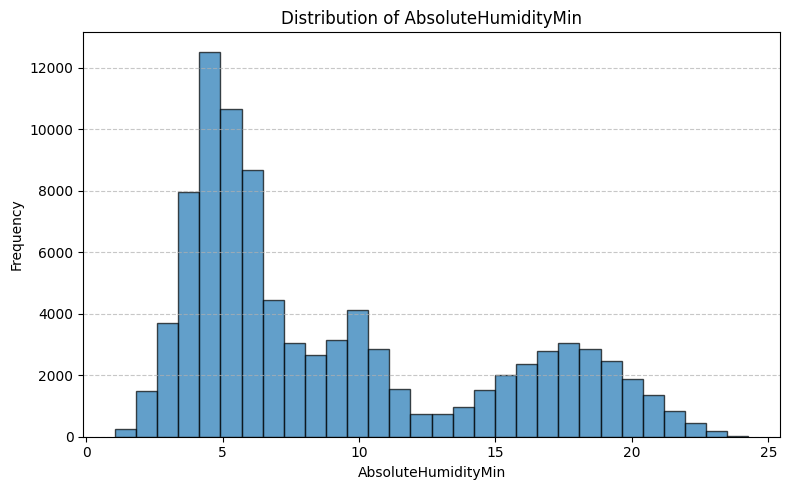

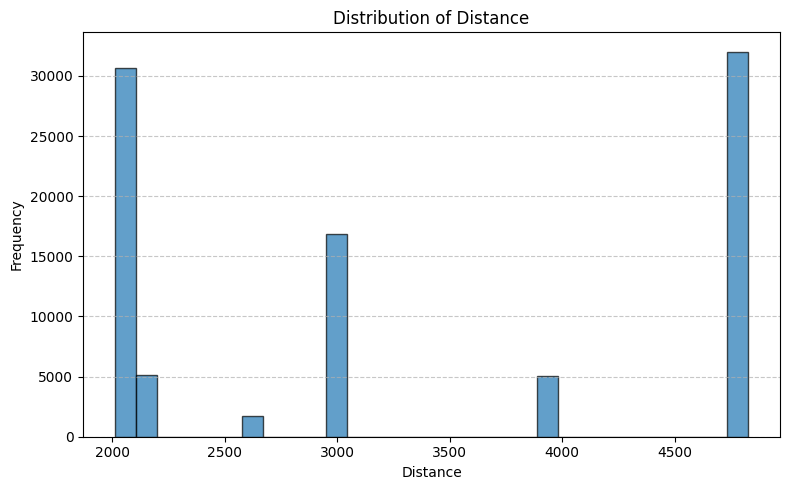

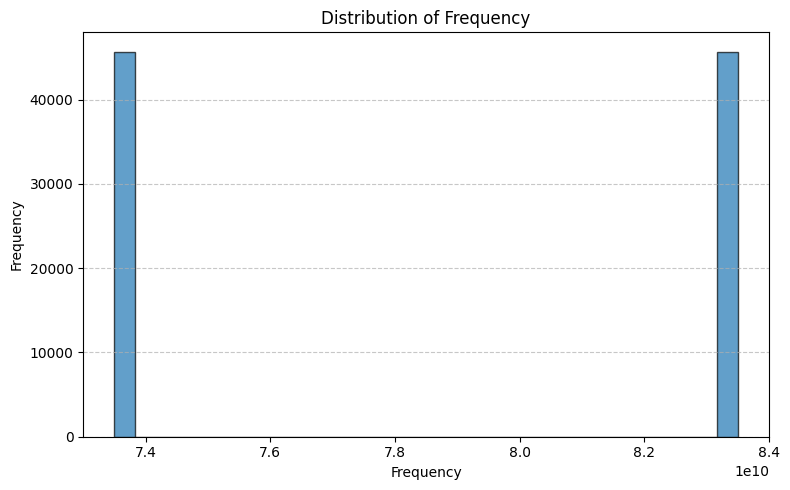

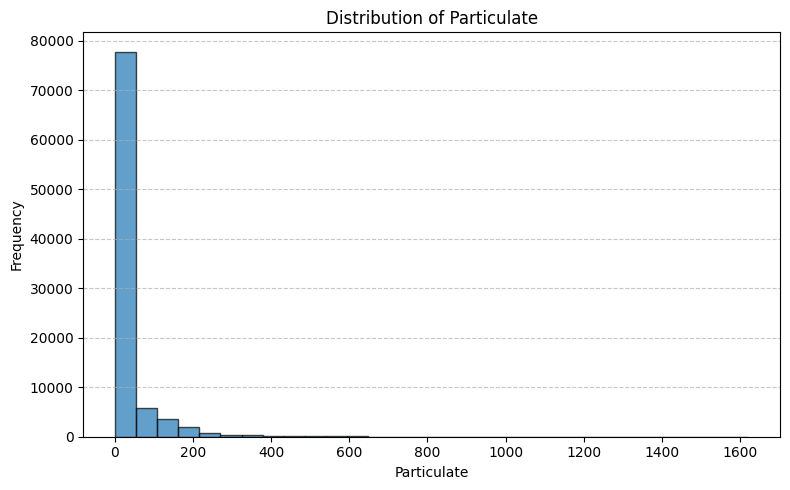

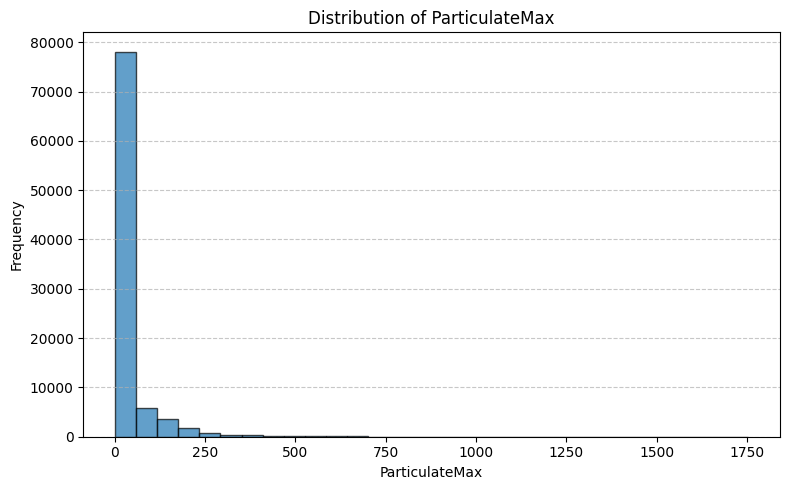

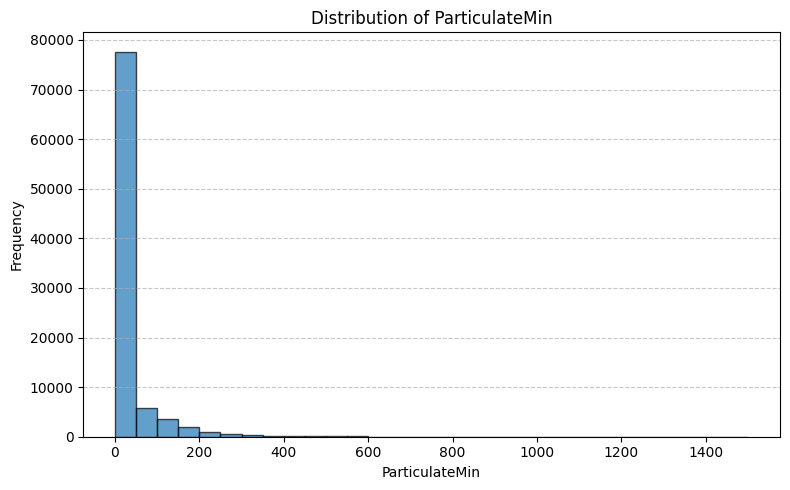

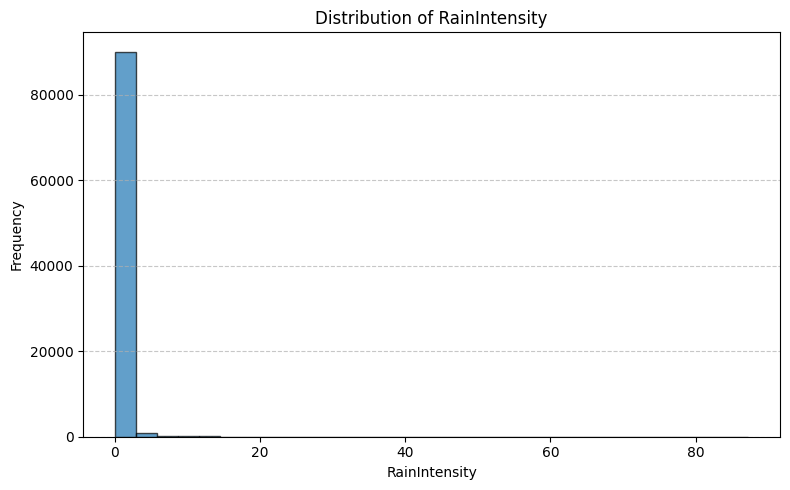

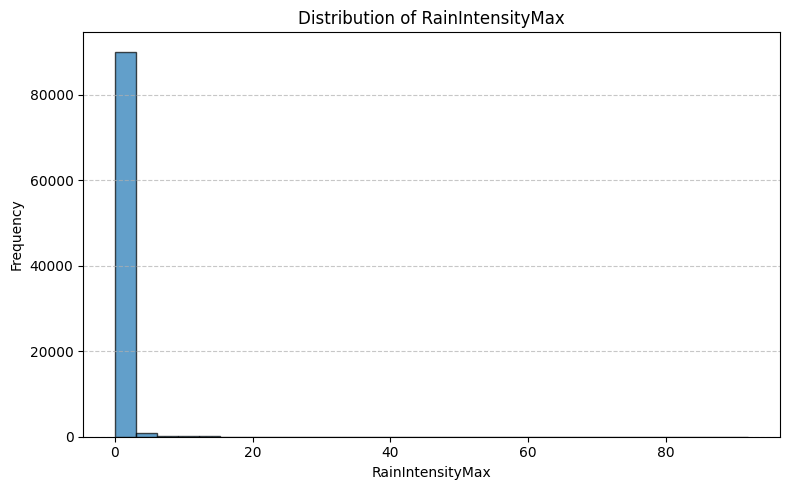

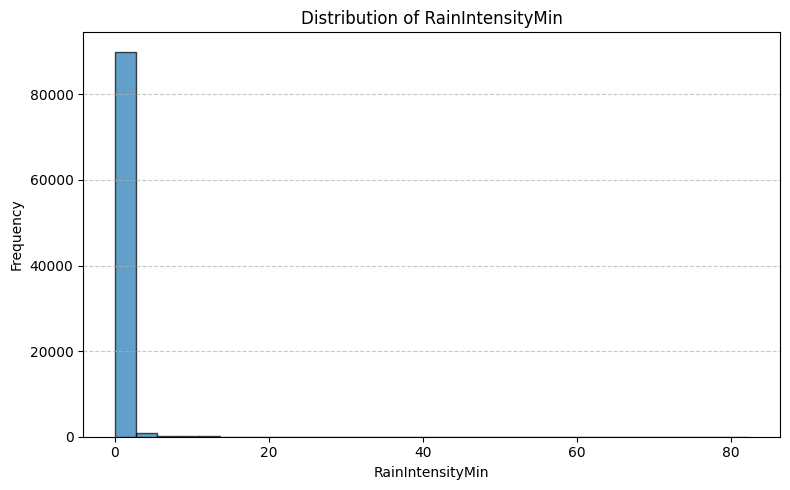

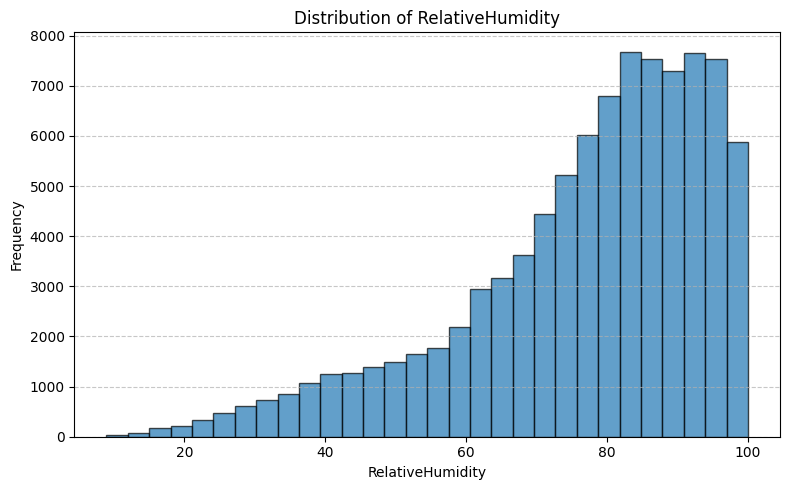

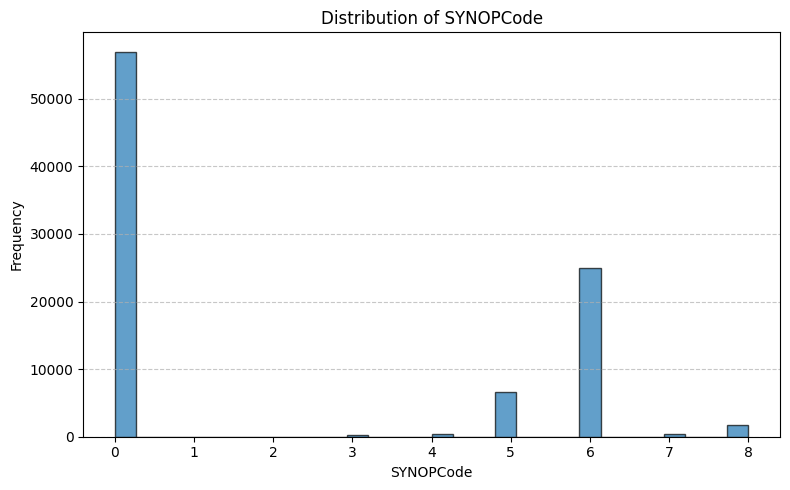

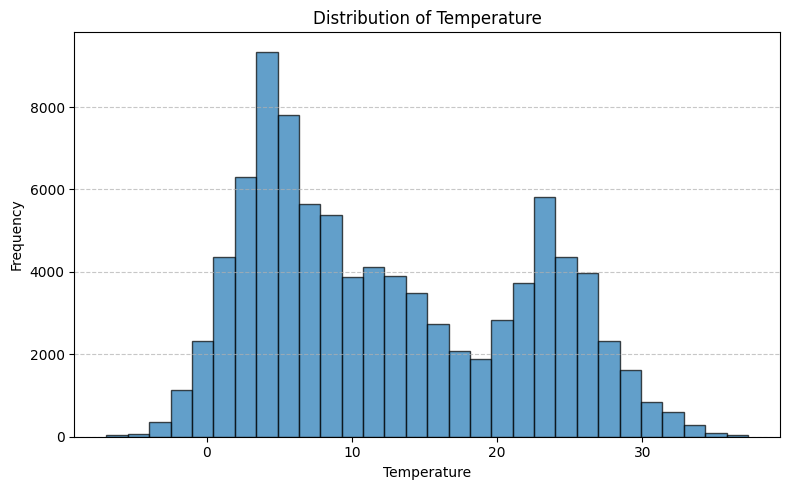

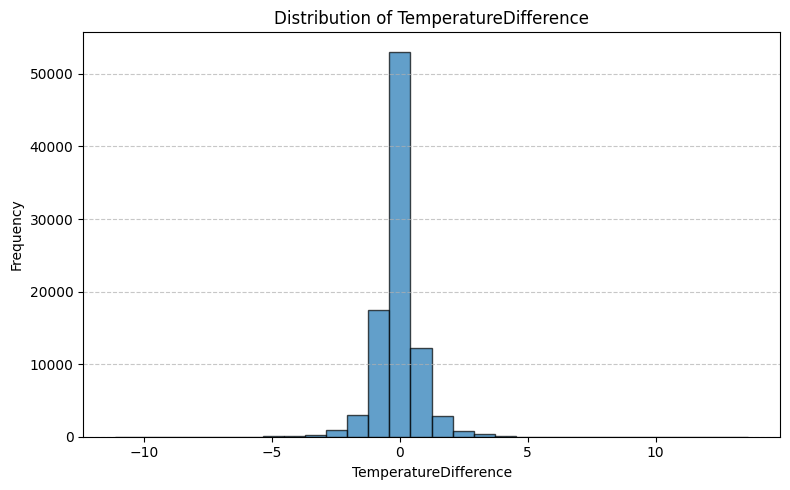

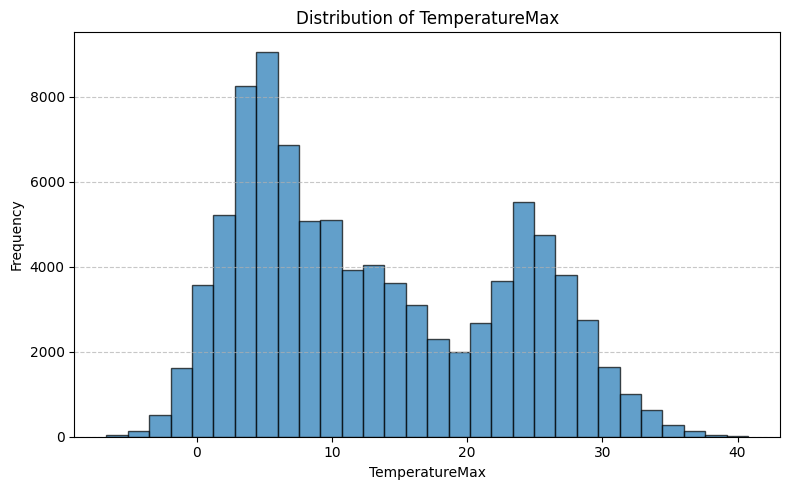

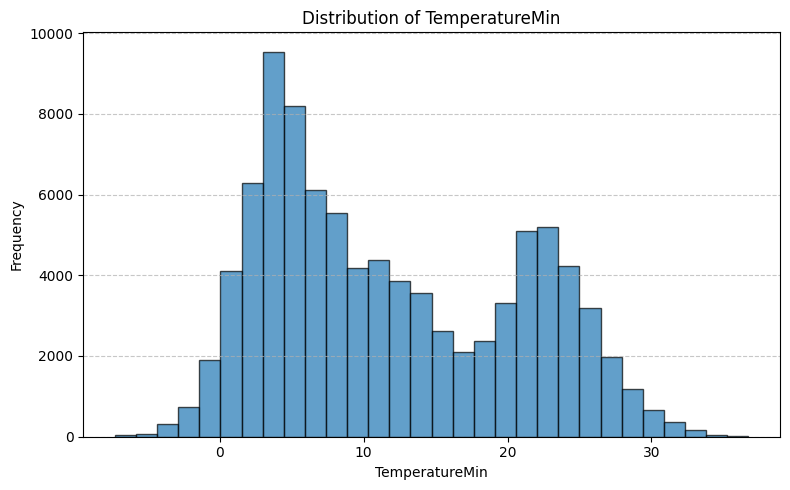

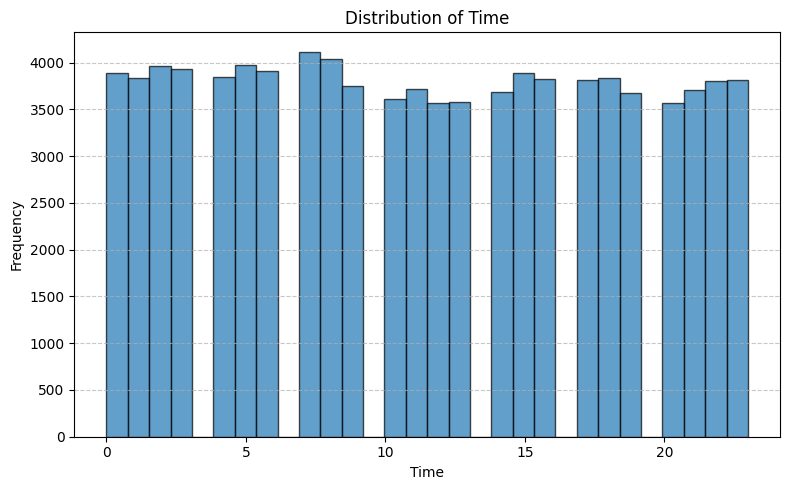

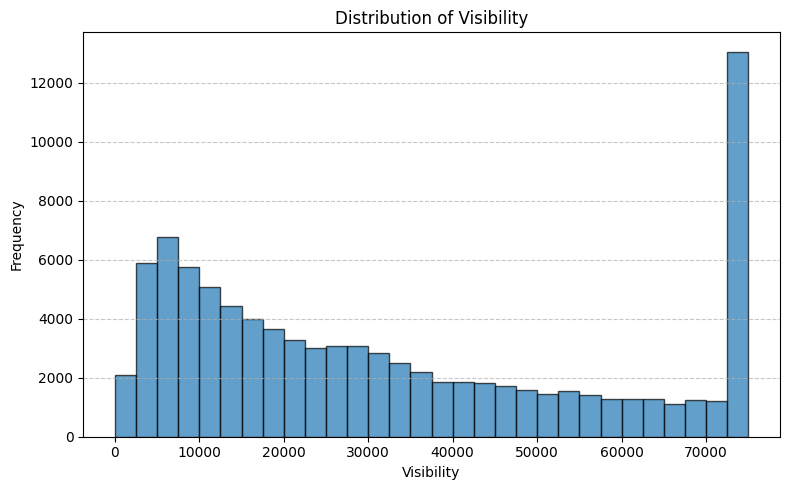

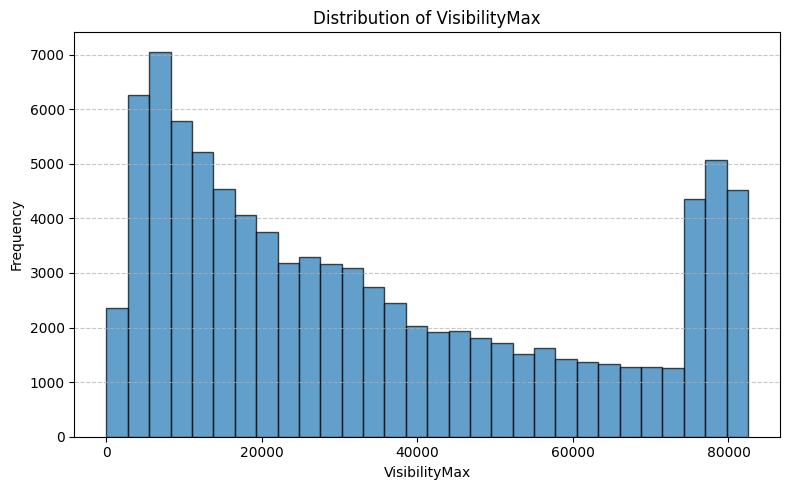

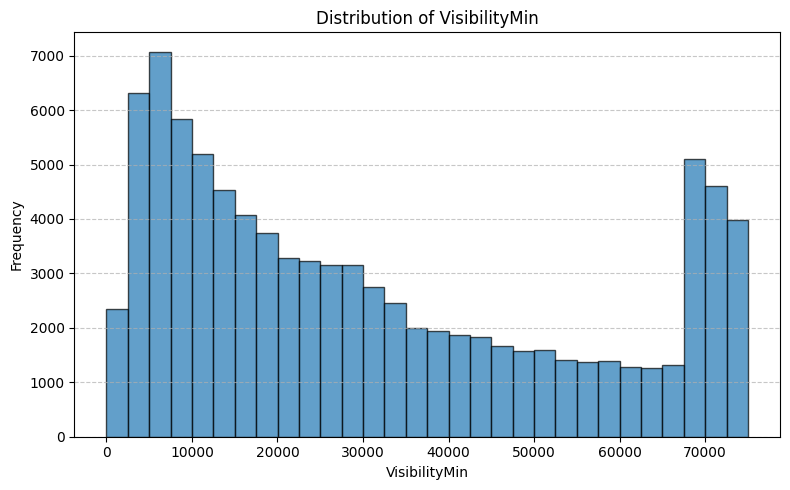

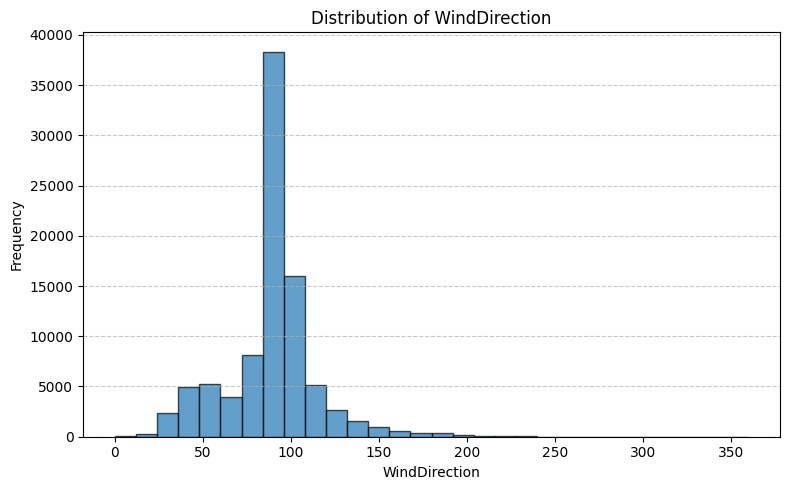

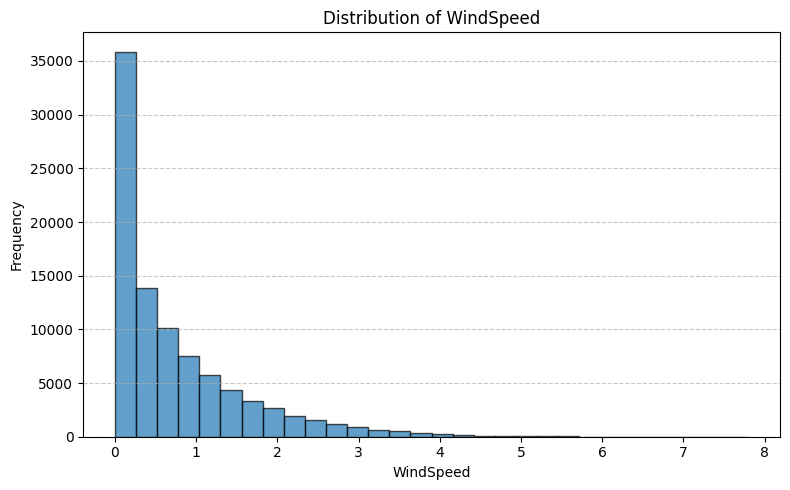

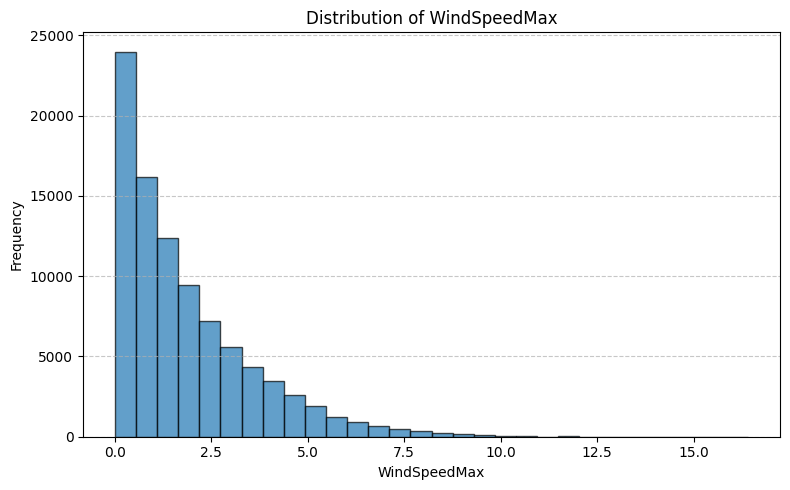

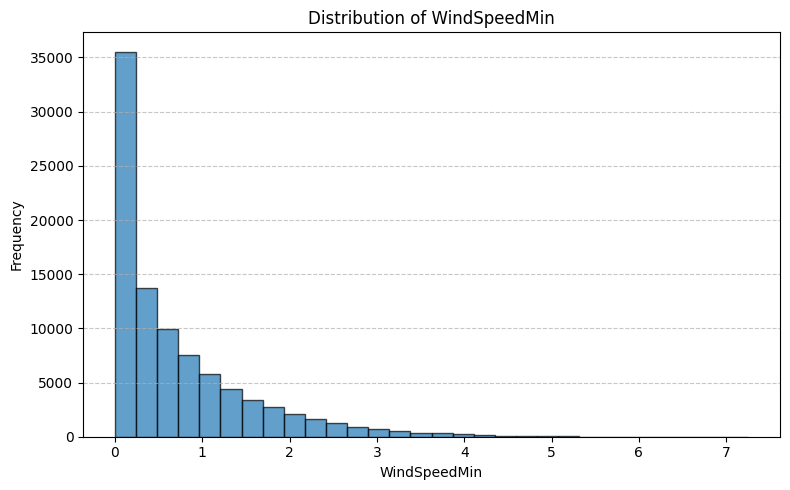

In [6]:
# Distribution of each feature — helps identify skewness and outliers
for column in rflfso_data.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(rflfso_data[column], bins=30, edgecolor='k', alpha=0.7)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

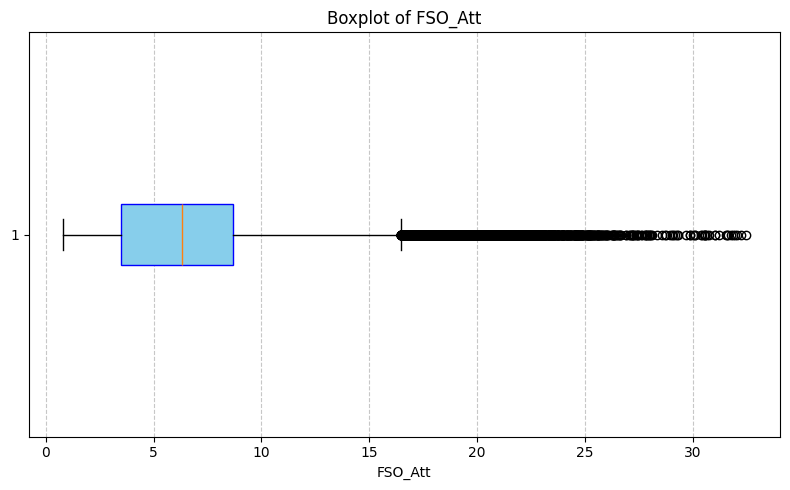

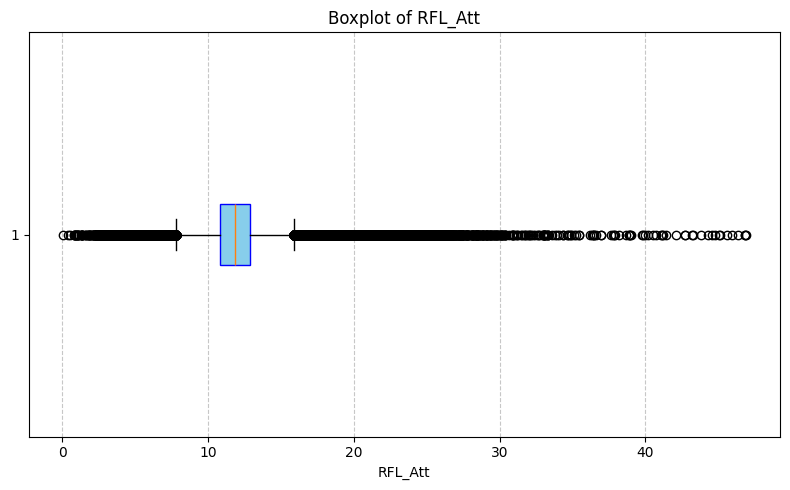

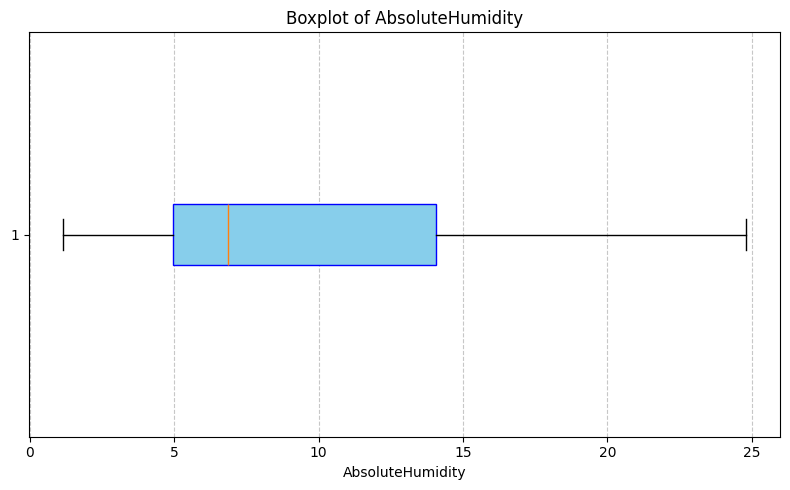

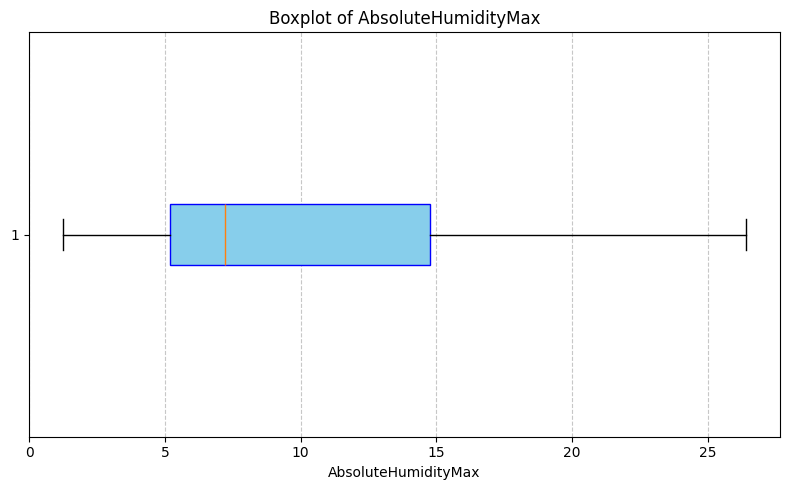

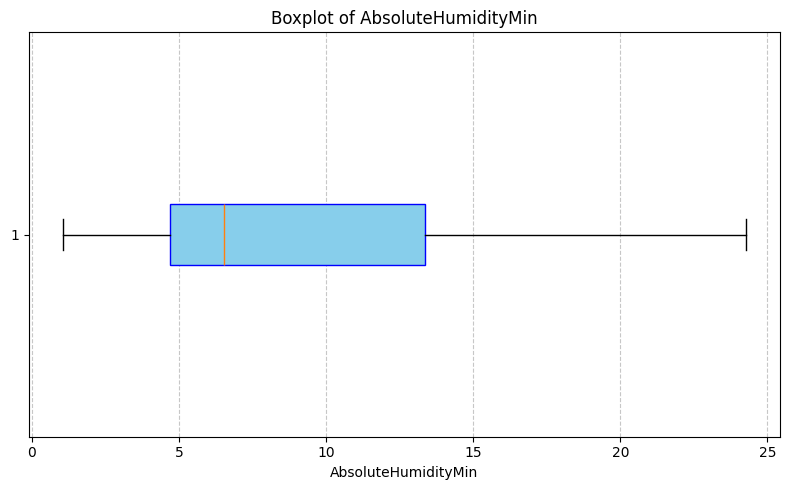

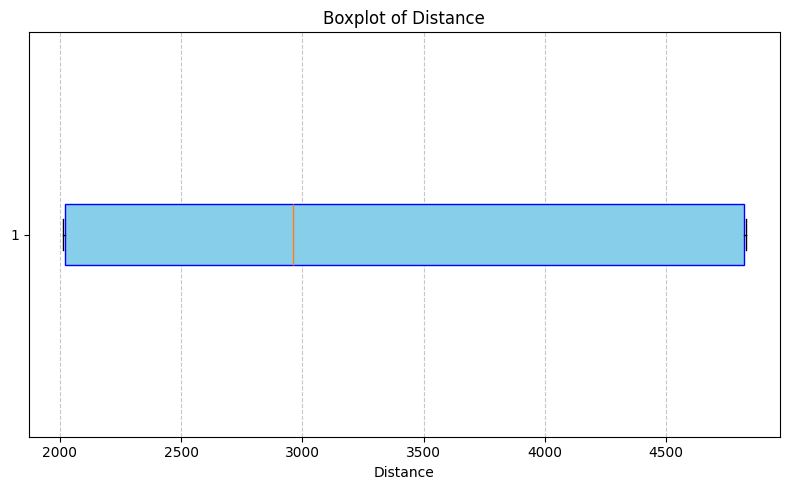

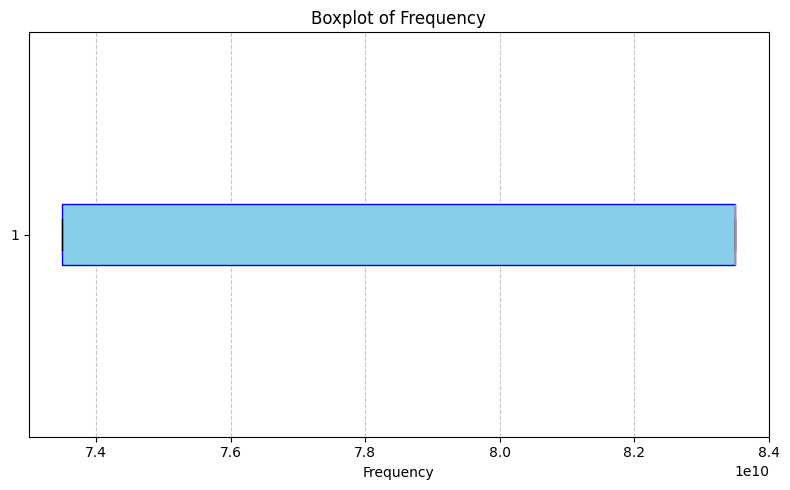

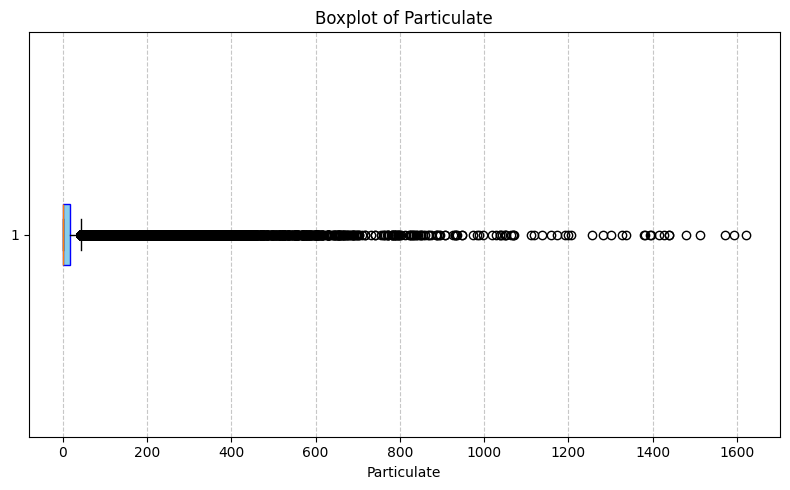

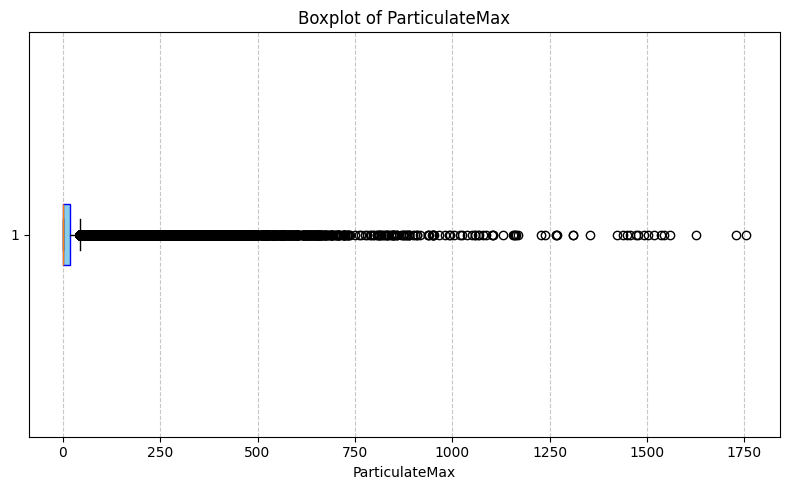

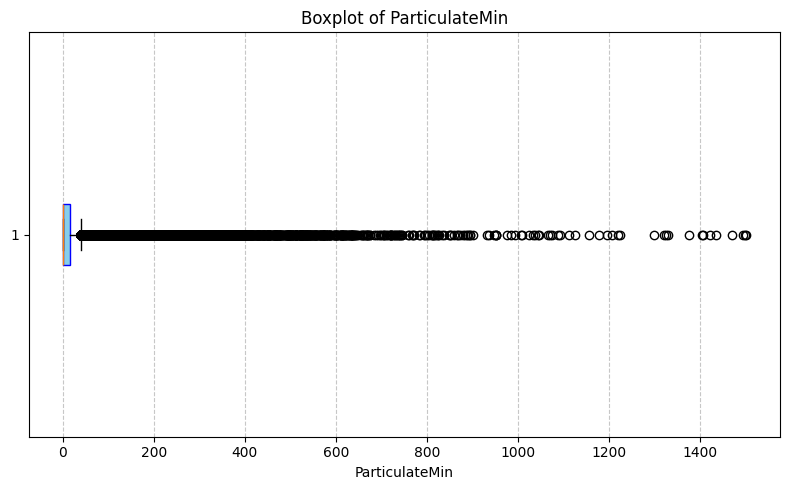

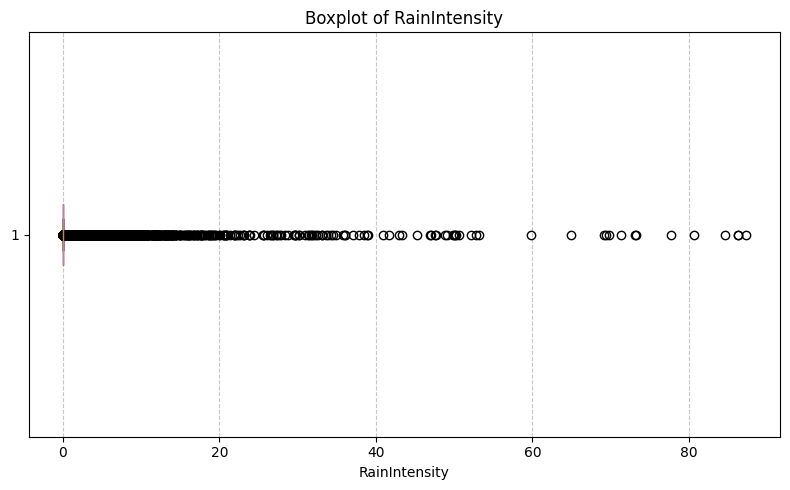

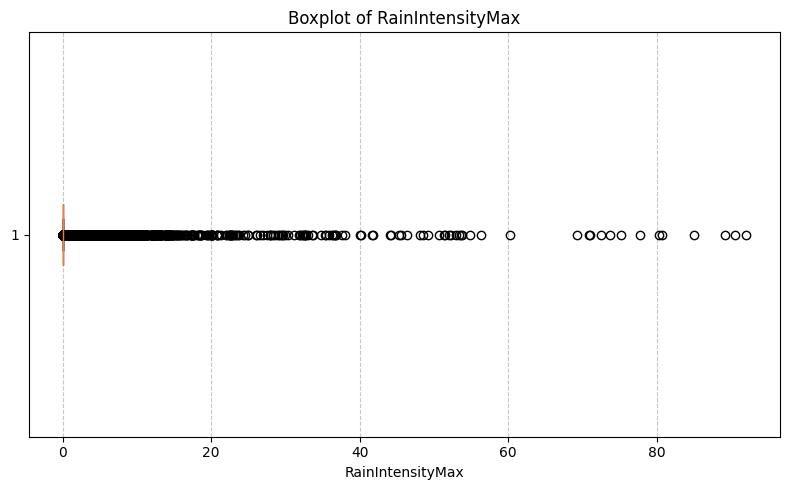

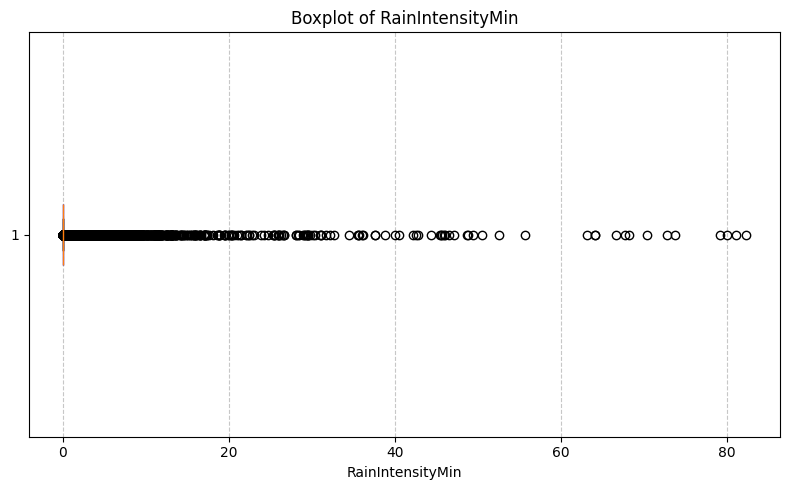

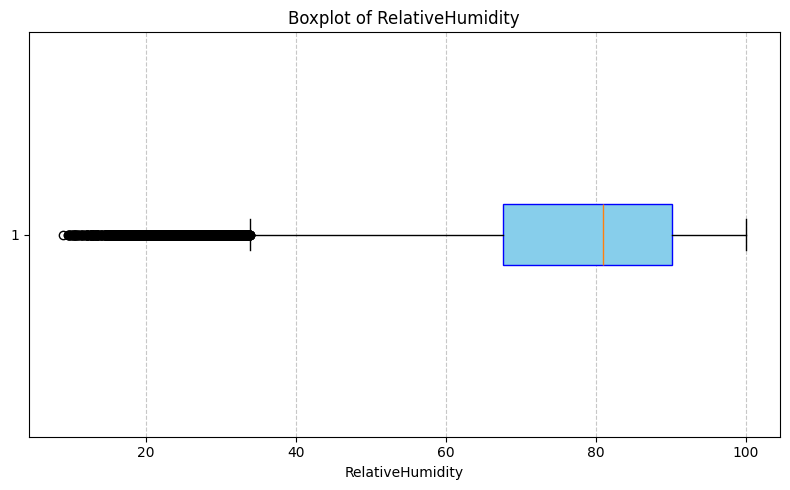

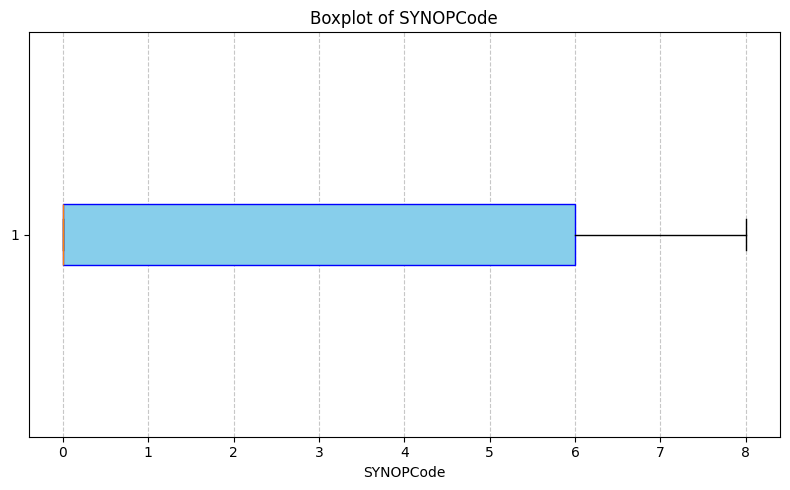

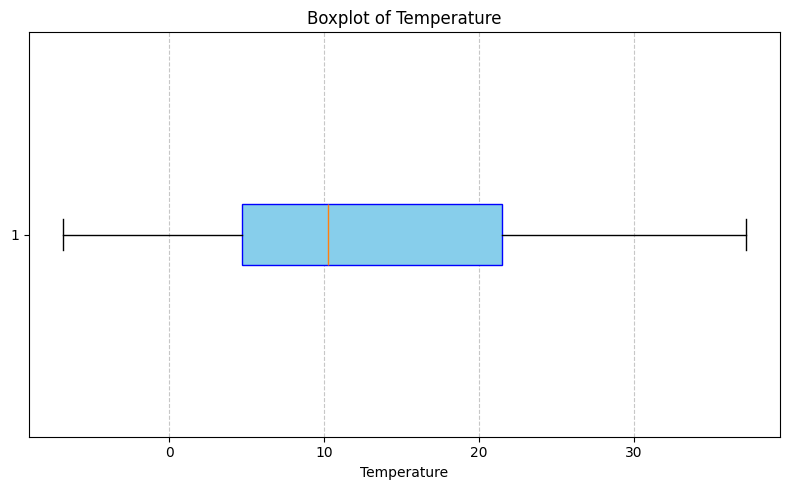

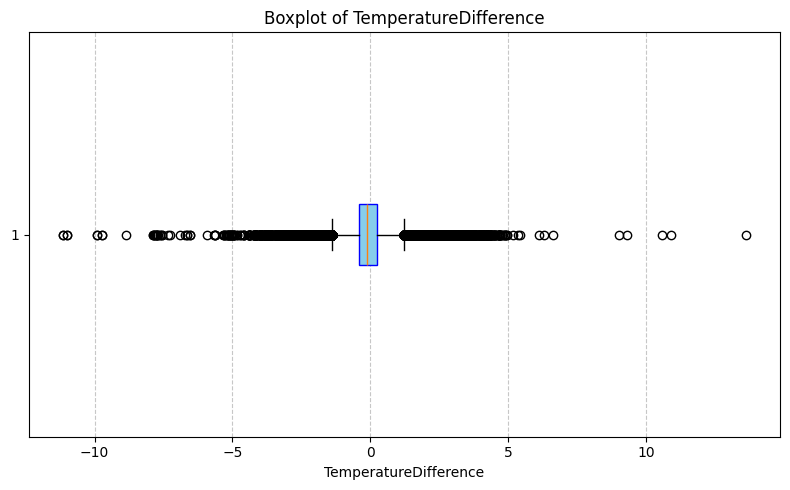

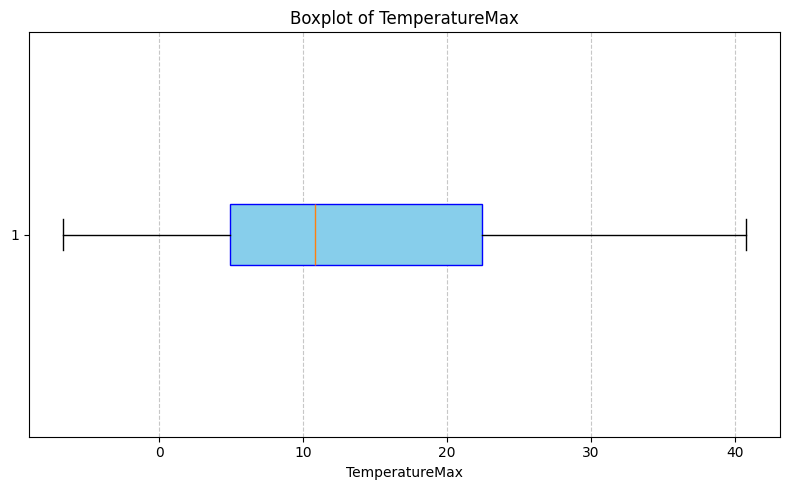

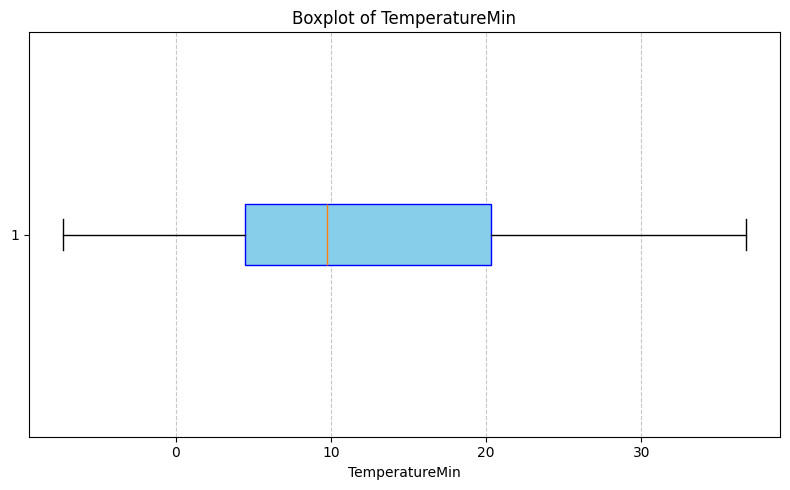

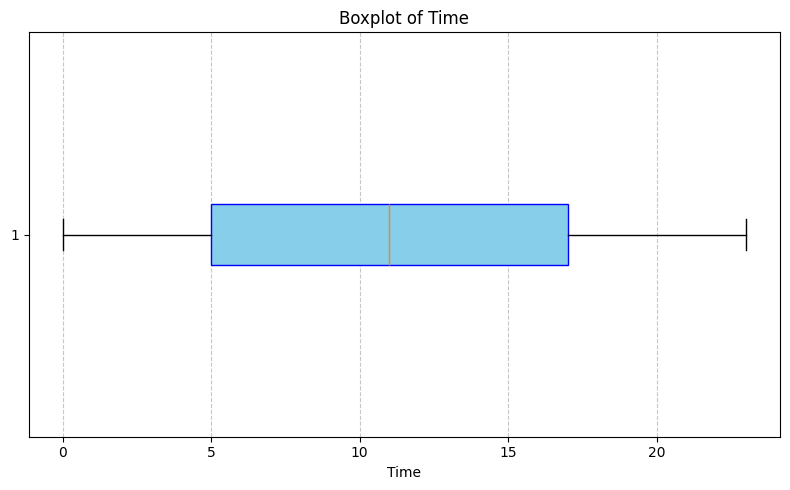

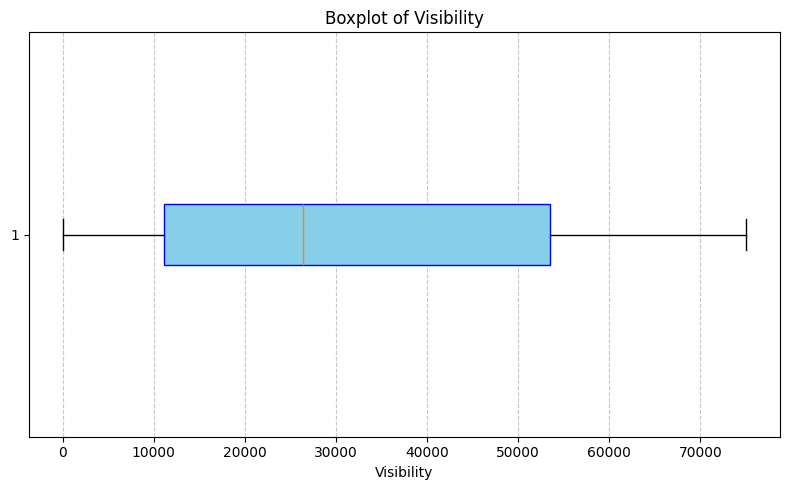

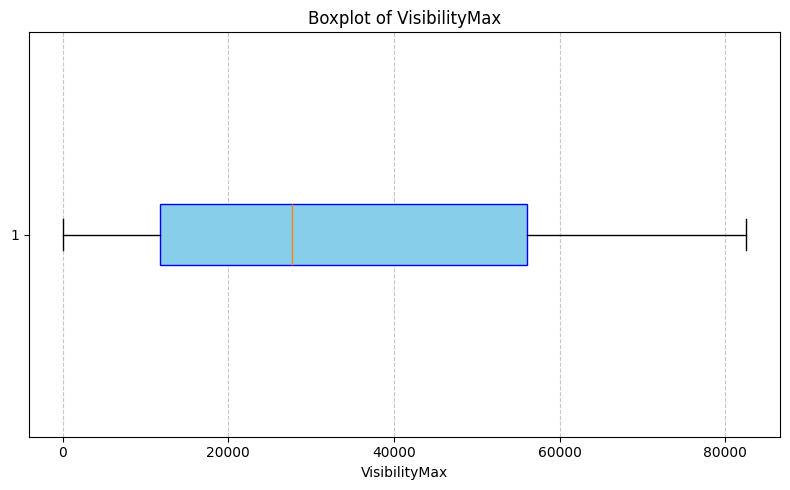

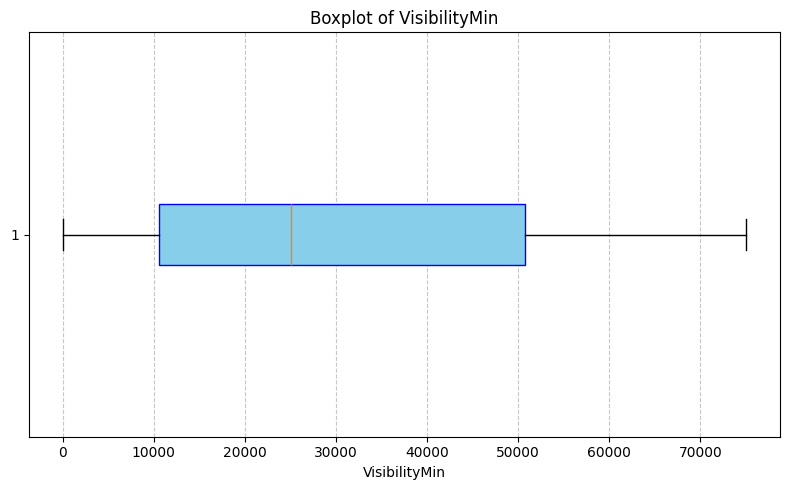

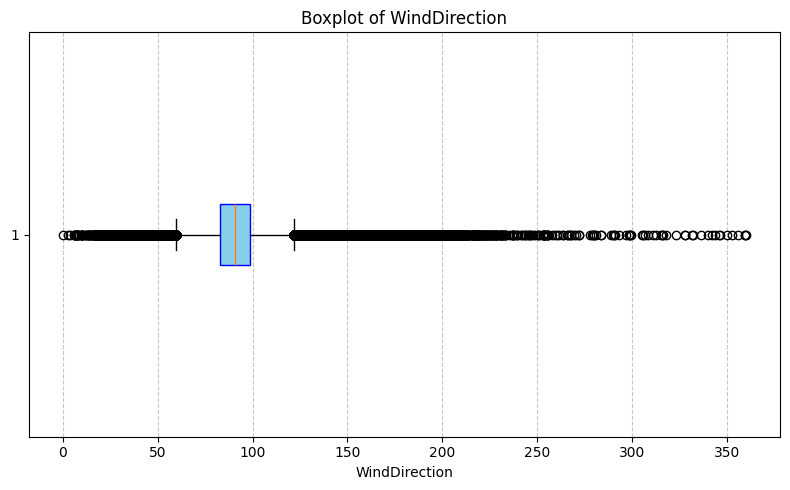

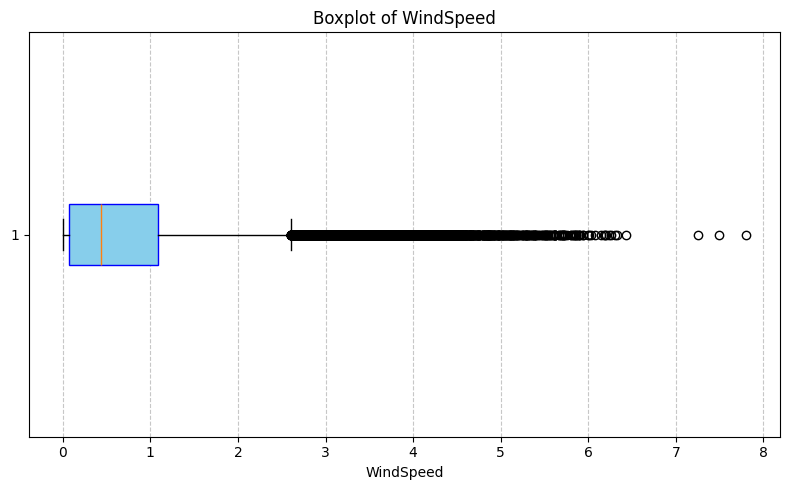

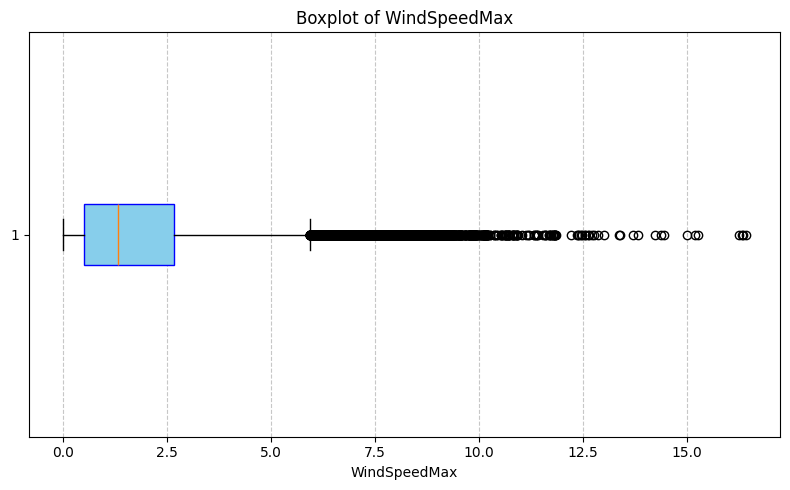

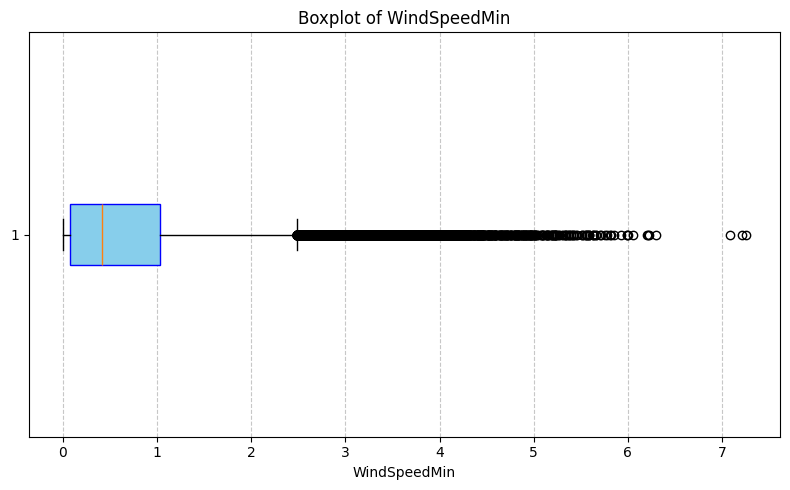

In [7]:
# Boxplots to identify outliers per feature
for column in rflfso_data.columns:
    plt.figure(figsize=(8, 5))
    plt.boxplot(
        rflfso_data[column], vert=False, patch_artist=True,
        boxprops=dict(facecolor='skyblue', color='blue')
    )
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

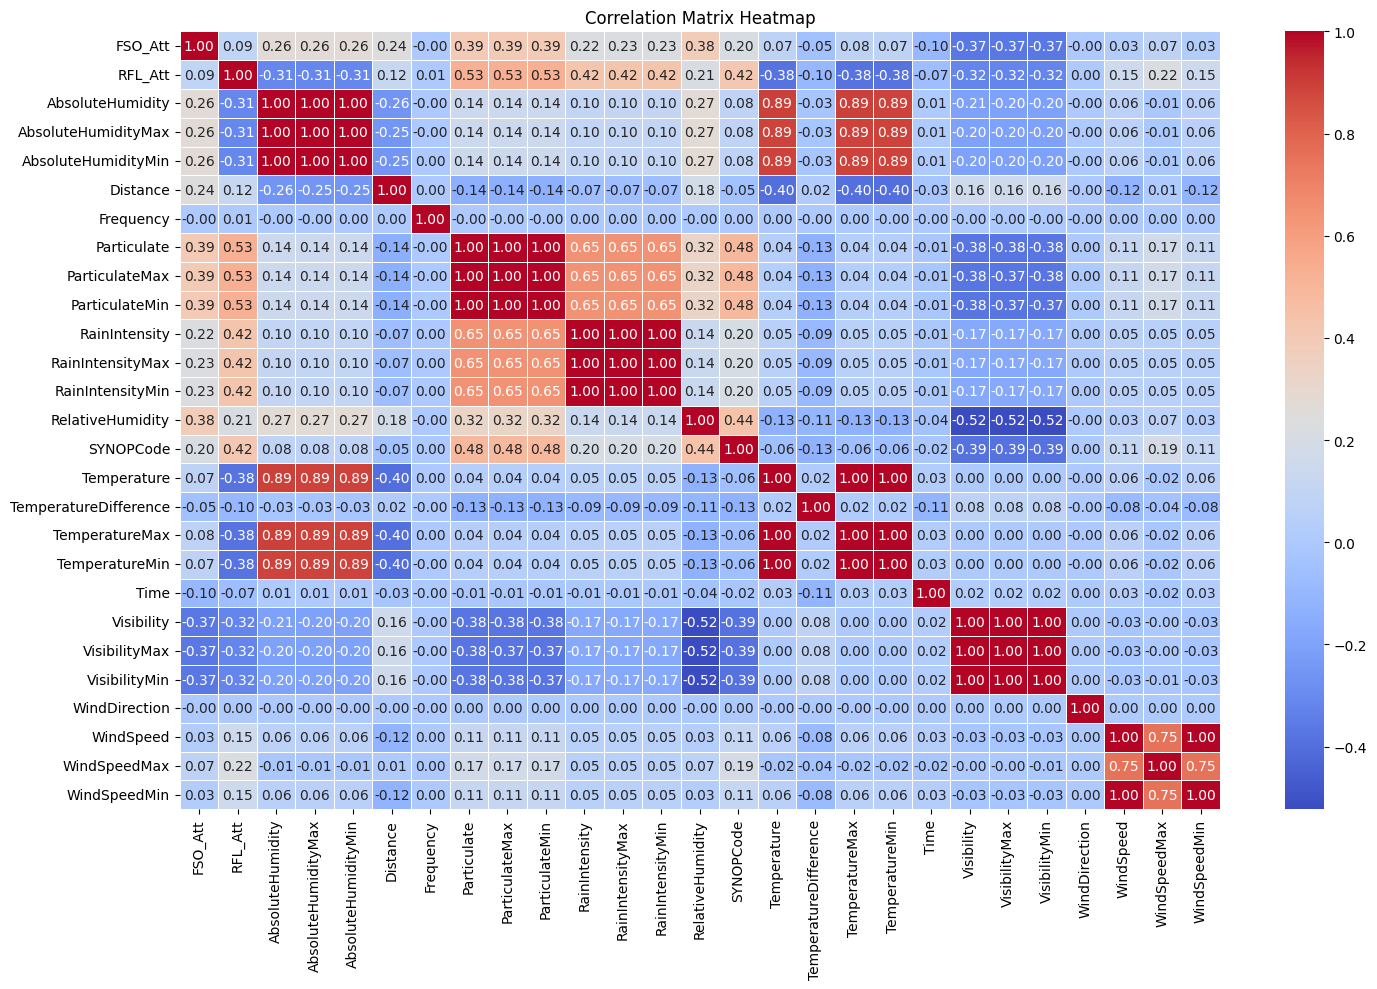

In [8]:
# Correlation heatmap — understand linear relationships between all features
plt.figure(figsize=(15, 10))
sns.heatmap(
    rflfso_data.corr(), annot=True, cmap='coolwarm',
    fmt='.2f', linewidths=0.5
)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

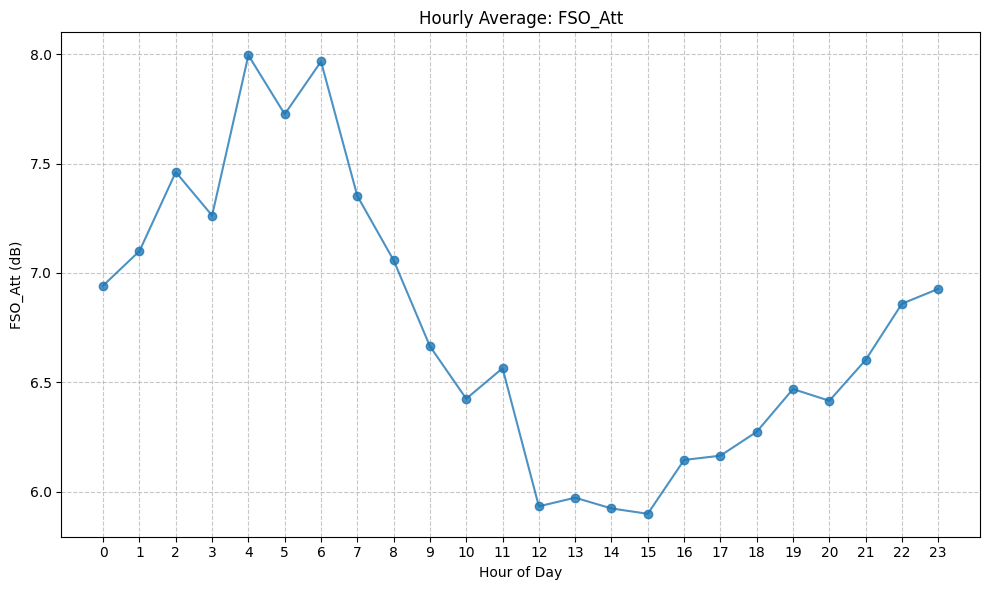

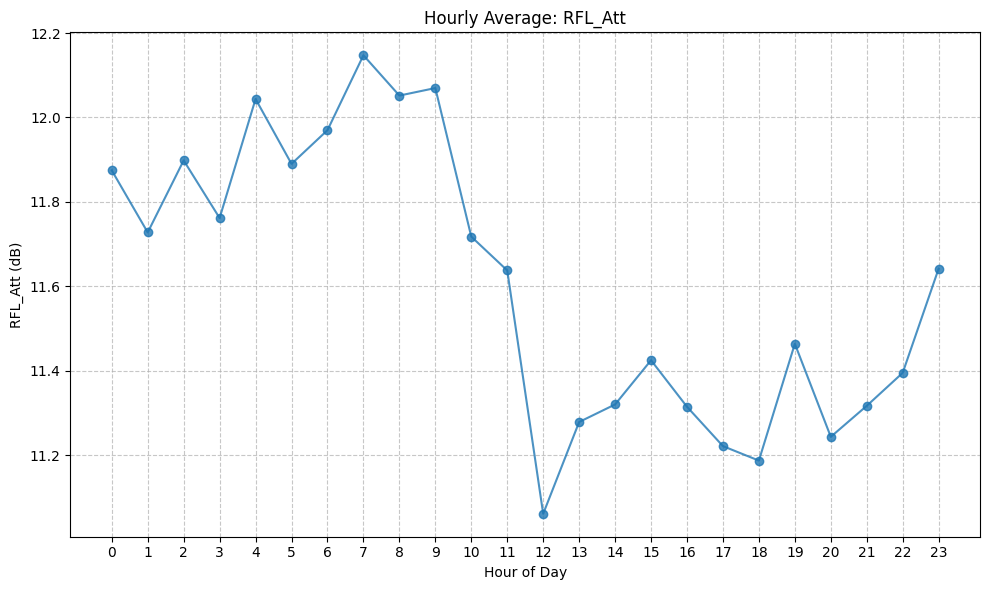

In [9]:
# Time trend: hourly average FSO and RF attenuation
# Reveals whether time of day influences signal degradation
rflfso_data['HourOfDay'] = rflfso_data['Time'] % 24
key_columns = ['FSO_Att', 'RFL_Att']
hourly_means = rflfso_data.groupby('HourOfDay')[key_columns].mean()

for column in key_columns:
    plt.figure(figsize=(10, 6))
    plt.plot(hourly_means.index, hourly_means[column], marker='o', linestyle='-', alpha=0.8)
    plt.title(f'Hourly Average: {column}')
    plt.xlabel('Hour of Day')
    plt.ylabel(f'{column} (dB)')
    plt.xticks(hourly_means.index)
    plt.grid(linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

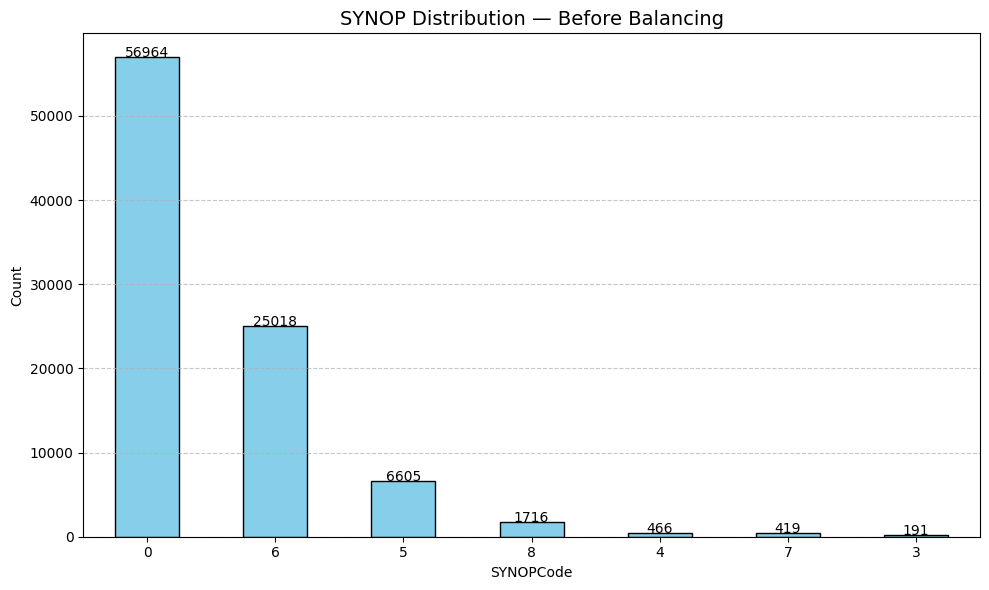

In [10]:
# SYNOP code distribution — check class imbalance across weather conditions
def plot_synop_counts(data, title='Distribution of SYNOP Weather Conditions'):
    synop_counts = data['SYNOPCode'].value_counts()

    plt.figure(figsize=(10, 6))
    ax = synop_counts.plot(kind='bar', color='skyblue', edgecolor='black')

    # Annotate bar heights
    for i, val in enumerate(synop_counts):
        plt.text(i, val + 0.5, str(val), ha='center', fontsize=10)

    plt.title(title, fontsize=14)
    plt.xlabel('SYNOPCode')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_synop_counts(rflfso_data, title='SYNOP Distribution — Before Balancing')

## 4. Data Balancing

The dataset has unequal representation across SYNOP weather condition categories. A model trained on imbalanced data will be biased toward common conditions and perform poorly on rare ones.

We balance by resampling each category to the median count:
- **Over-represented categories** → down-sampled (without replacement)
- **Under-represented categories** → over-sampled (with replacement)

Median count per SYNOP category: 1716
Balanced dataset size: 12012 rows


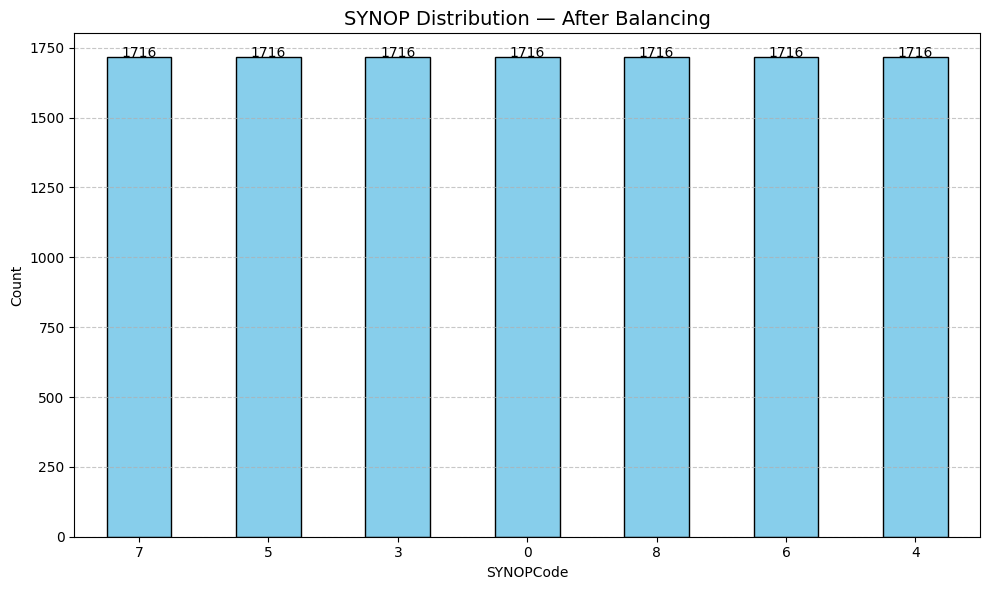

In [11]:
synop_counts  = rflfso_data['SYNOPCode'].value_counts()
median_count  = int(synop_counts.median())
print(f"Median count per SYNOP category: {median_count}")

balanced_groups = []
for code in synop_counts.index:
    group = rflfso_data[rflfso_data['SYNOPCode'] == code]

    if len(group) > median_count:
        # Down-sample majority classes
        balanced_group = resample(group, replace=False, n_samples=median_count, random_state=42)
    elif len(group) < median_count:
        # Over-sample minority classes
        balanced_group = resample(group, replace=True, n_samples=median_count, random_state=42)
    else:
        balanced_group = group

    balanced_groups.append(balanced_group)

# Combine and shuffle
balanced_data = pd.concat(balanced_groups).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Balanced dataset size: {balanced_data.shape[0]} rows")

plot_synop_counts(balanced_data, title='SYNOP Distribution — After Balancing')

## 5. Feature Selection

We use **backward elimination** with a Random Forest to identify the most important features for each target:
- At each step, train RF on remaining features, record RMSE and R²
- Remove the least important feature
- Plot RMSE and R² vs removed features to identify the cutoff point where performance stabilises

Cutoff indices (identified by visual inspection of RMSE/R² stabilisation): FSO = 12, RFL = 9 — features removed after this point caused meaningful degradation when absent

In [12]:
def plot_feature_selection_results(results, target, title):
    """
    Plot RMSE and R² against removed features with a cutoff line.

    Args:
        results (DataFrame): Feature selection results with columns
                             ['Removed Feature', 'RMSE', 'R2'].
        target (str): Target variable name ('FSO_Att' or 'RFL_Att').
        title (str): Plot title.
    """
    # Cutoff index: point where RMSE stabilises / R² plateaus
    cutoff_index = 12 if target == 'FSO_Att' else 9

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # RMSE on primary y-axis
    ax1.plot(results['Removed Feature'], results['RMSE'],
             label='RMSE', color='blue', marker='o', markersize=5)
    ax1.set_xlabel('Removed Feature', fontsize=12)
    ax1.set_ylabel('RMSE', fontsize=12, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(range(len(results)))
    ax1.set_xticklabels(results['Removed Feature'], rotation=45, ha='right', fontsize=10)

    # R² on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results['Removed Feature'], results['R2'],
             label='R²', color='red', marker='o', markersize=5)
    ax2.set_ylabel('R²', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Vertical cutoff line
    ax1.axvline(x=cutoff_index, color='green', linestyle='--', label='Feature Cutoff')

    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.legend(loc='upper left', fontsize=10)
    ax2.legend(loc='upper right', fontsize=10)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

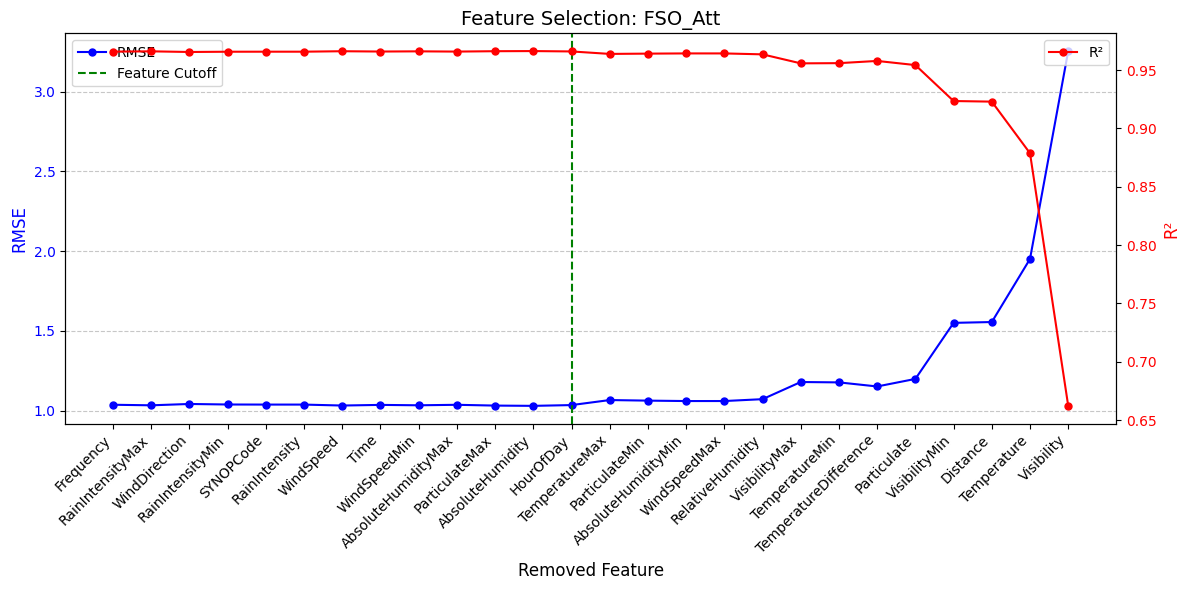

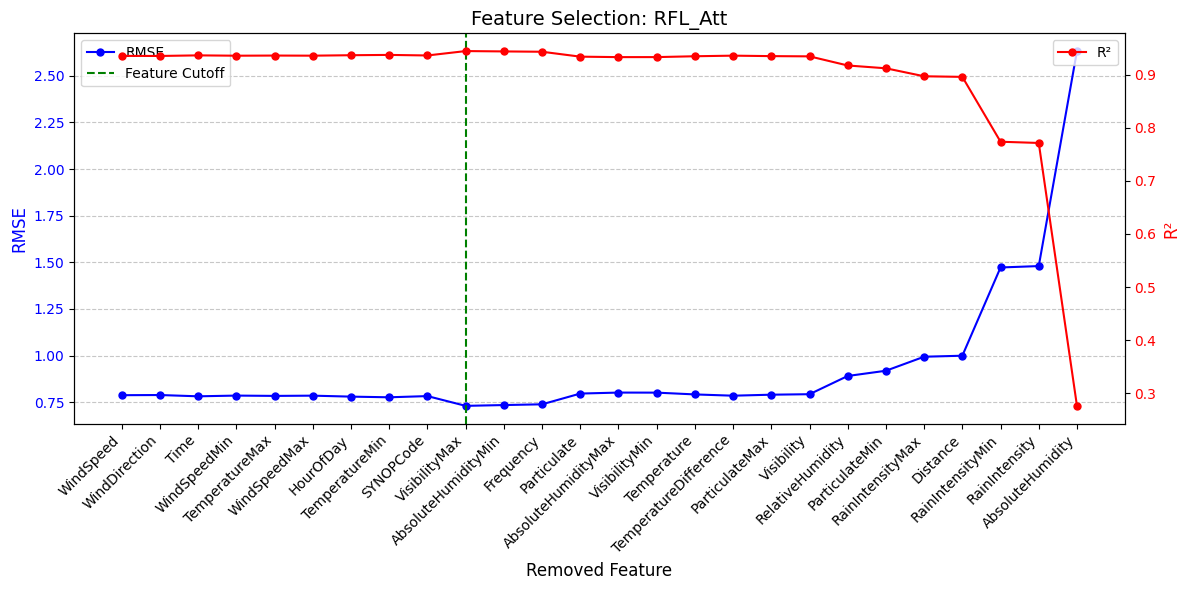

In [13]:
def feature_selection(data, target, plot_cutoff=False):
    """
    Backward elimination feature selection using Random Forest.

    Iteratively removes the least important feature and records model
    performance (RMSE, R²) at each step. Optionally plots the results.

    Args:
        data (DataFrame): Balanced dataset.
        target (str): Target column name.
        plot_cutoff (bool): Whether to plot RMSE/R² vs removed features.

    Returns:
        DataFrame: Results table with columns ['Removed Feature', 'RMSE', 'R2'].
    """
    # Exclude both target columns and use all others as candidate features
    non_predictor_cols = [target, 'FSO_Att', 'RFL_Att']
    S = [col for col in data.columns if col not in non_predictor_cols]
    results = []

    while S:
        X_train, X_test, y_train, y_test = train_test_split(
            data[S], data[target], test_size=0.2, random_state=42
        )

        rf = RandomForestRegressor(random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        rmse = root_mean_squared_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        # Identify and remove the least important feature
        importances = pd.Series(rf.feature_importances_, index=S)
        least_important = importances.idxmin()
        S.remove(least_important)

        results.append({'Removed Feature': least_important, 'RMSE': rmse, 'R2': r2})

    results_df = pd.DataFrame(results)

    if plot_cutoff:
        plot_feature_selection_results(results_df, target, f'Feature Selection: {target}')

    return results_df


# Run feature selection for both targets
fso_selection_results = feature_selection(balanced_data, 'FSO_Att', plot_cutoff=True)
rfl_selection_results = feature_selection(balanced_data, 'RFL_Att', plot_cutoff=True)

In [14]:
# Extract selected features based on cutoff indices identified from the plots
# In backward elimination, features removed last are the most important.
# Slicing from the cutoff index onwards gives us the features whose removal degraded performance most.
fso_features = fso_selection_results['Removed Feature'].iloc[12:].tolist()
rfl_features = rfl_selection_results['Removed Feature'].iloc[9:].tolist()

print(f"FSO selected features ({len(fso_features)}): {fso_features}")
print(f"RFL selected features ({len(rfl_features)}): {rfl_features}")

FSO selected features (14): ['HourOfDay', 'TemperatureMax', 'ParticulateMin', 'AbsoluteHumidityMin', 'WindSpeedMax', 'RelativeHumidity', 'VisibilityMax', 'TemperatureMin', 'TemperatureDifference', 'Particulate', 'VisibilityMin', 'Distance', 'Temperature', 'Visibility']
RFL selected features (17): ['VisibilityMax', 'AbsoluteHumidityMin', 'Frequency', 'Particulate', 'AbsoluteHumidityMax', 'VisibilityMin', 'Temperature', 'TemperatureDifference', 'ParticulateMax', 'Visibility', 'RelativeHumidity', 'ParticulateMin', 'RainIntensityMax', 'Distance', 'RainIntensityMin', 'RainIntensity', 'AbsoluteHumidity']


In [15]:
# Build feature-selected datasets for each target
# SYNOPCode retained for condition-specific modelling
ds_fso_data = balanced_data[fso_features + ['FSO_Att', 'SYNOPCode']]
ds_rfl_data = balanced_data[rfl_features + ['RFL_Att', 'SYNOPCode']]

print("FSO dataset shape:", ds_fso_data.shape)
print("RFL dataset shape:", ds_rfl_data.shape)

FSO dataset shape: (12012, 16)
RFL dataset shape: (12012, 19)


## 6. Model Training

### Strategy 1 — Specific Model (per weather condition)
Train a separate Random Forest for each SYNOP weather condition. This assumes that attenuation patterns differ significantly between weather types (e.g. fog vs clear sky).

In [16]:
def train_random_forest_by_condition(data, target_column, condition_column):
    """
    Train a separate Random Forest model for each unique weather condition.

    Args:
        data (DataFrame): Feature-selected dataset including target and condition columns.
        target_column (str): Column to predict.
        condition_column (str): Column defining weather conditions (SYNOPCode).

    Returns:
        dict: Trained models per condition, plus mean RMSE and R² across all conditions.
    """
    condition_models = {}
    all_rmse, all_r2 = [], []

    for condition in data[condition_column].unique():
        subset = data[data[condition_column] == condition]
        X = subset.drop(columns=[target_column, condition_column])
        y = subset[target_column]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        rf = RandomForestRegressor(random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        rmse = root_mean_squared_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        print(f"  Condition {condition} — RMSE: {rmse:.4f} | R²: {r2:.4f}")
        condition_models[condition] = {'model': rf, 'rmse': rmse, 'r2': r2}
        all_rmse.append(rmse)
        all_r2.append(r2)

    return {'models': condition_models, 'rmse': np.mean(all_rmse), 'r2': np.mean(all_r2)}


print("Training FSO specific models...")
fso_specific = train_random_forest_by_condition(ds_fso_data, 'FSO_Att', 'SYNOPCode')

print("\nTraining RFL specific models...")
rfl_specific = train_random_forest_by_condition(ds_rfl_data, 'RFL_Att', 'SYNOPCode')

Training FSO specific models...
  Condition 7 — RMSE: 0.2203 | R²: 0.9984
  Condition 5 — RMSE: 1.2720 | R²: 0.8889
  Condition 3 — RMSE: 0.1888 | R²: 0.9995
  Condition 0 — RMSE: 1.2339 | R²: 0.8607
  Condition 8 — RMSE: 1.0914 | R²: 0.9321
  Condition 6 — RMSE: 1.5780 | R²: 0.8632
  Condition 4 — RMSE: 0.1459 | R²: 0.9985

Training RFL specific models...
  Condition 7 — RMSE: 0.0717 | R²: 0.9977
  Condition 5 — RMSE: 1.0184 | R²: 0.8807
  Condition 3 — RMSE: 0.0105 | R²: 1.0000
  Condition 0 — RMSE: 0.5296 | R²: 0.9565
  Condition 8 — RMSE: 1.1819 | R²: 0.8713
  Condition 6 — RMSE: 0.8957 | R²: 0.9398
  Condition 4 — RMSE: 0.0951 | R²: 0.9968


### Strategy 2 — Generic Model (single model across all conditions)
Train one Random Forest on all weather conditions combined. SYNOPCode is included as a feature so the model can learn condition-specific patterns without needing separate models.

In [17]:
def train_generic_random_forest(data, target_column):
    """
    Train a single Random Forest model across all weather conditions.

    Args:
        data (DataFrame): Feature-selected dataset including the target column.
        target_column (str): Column to predict.

    Returns:
        dict: Trained model, RMSE, and R².
    """
    X = data.drop(columns=[target_column])
    y = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"RMSE: {rmse:.4f} | R²: {r2:.4f}")
    return {'model': rf, 'rmse': rmse, 'r2': r2}


print("FSO generic model:")
fso_generic = train_generic_random_forest(ds_fso_data, 'FSO_Att')

print("\nRFL generic model:")
rfl_generic = train_generic_random_forest(ds_rfl_data, 'RFL_Att')

FSO generic model:
RMSE: 1.0281 | R²: 0.9663

RFL generic model:
RMSE: 0.7812 | R²: 0.9363


## 7. Results Comparison

Compare the specific (per-condition) vs generic (combined) models for both FSO and RF attenuation.

In [18]:
# Summary table
comparison = pd.DataFrame({
    'Model':  ['FSO Specific', 'FSO Generic', 'RFL Specific', 'RFL Generic'],
    'RMSE':   [fso_specific['rmse'], fso_generic['rmse'],
               rfl_specific['rmse'], rfl_generic['rmse']],
    'R²':     [fso_specific['r2'],   fso_generic['r2'],
               rfl_specific['r2'],   rfl_generic['r2']]
}).set_index('Model').round(4)

print(comparison.to_string())

                RMSE      R²
Model                       
FSO Specific  0.8186  0.9345
FSO Generic   1.0281  0.9663
RFL Specific  0.5433  0.9490
RFL Generic   0.7812  0.9363


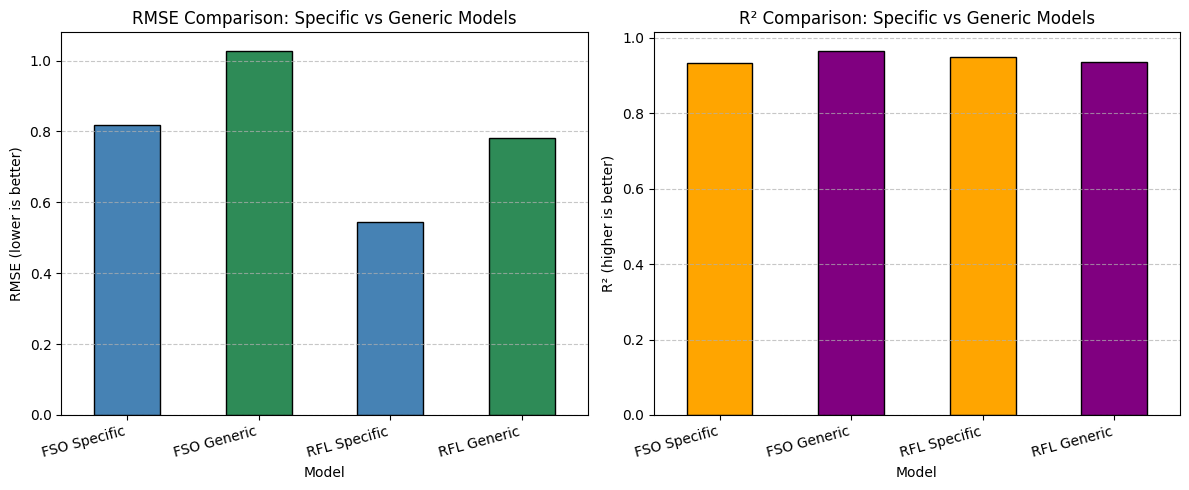

In [19]:
# RMSE comparison bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

comparison['RMSE'].plot(kind='bar', ax=ax1, color=['steelblue', 'seagreen', 'steelblue', 'seagreen'],
                        edgecolor='black')
ax1.set_title('RMSE Comparison: Specific vs Generic Models')
ax1.set_ylabel('RMSE (lower is better)')
ax1.set_xticklabels(comparison.index, rotation=15, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# R² comparison bar chart
comparison['R²'].plot(kind='bar', ax=ax2, color=['orange', 'purple', 'orange', 'purple'],
                      edgecolor='black')
ax2.set_title('R² Comparison: Specific vs Generic Models')
ax2.set_ylabel('R² (higher is better)')
ax2.set_xticklabels(comparison.index, rotation=15, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 8. Key Findings

| Finding | Detail |
|---------|--------|
| **SYNOP code** | Weather condition is the most important predictor of attenuation for both FSO and RF channels |
| **Specific vs Generic** | Condition-specific models achieve lower RMSE, confirming that attenuation patterns differ meaningfully across weather types |
| **Data balancing** | Resampling to median SYNOP count improved model performance on rare weather conditions |
| **Feature selection** | Backward elimination removed noisy features without hurting predictive accuracy |
| **FSO vs RF** | FSO attenuation is harder to predict (higher RMSE) due to its greater sensitivity to atmospheric conditions |

**Limitation:** The dataset mixes synthetic and empirical measurements. Models trained on synthetic data may overestimate performance on real-world conditions.